**Supply and Demand**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datascience import*
%matplotlib inline

In [ ]:
bananas = Table.read_table("banana_prices.csv") # read table
bananas.show(5) # show the first 5 rows to get an idea of the data

Day,Banana Price ($),Total Volume
1,1.4,967
2,0.73,939
3,1.04,925
4,1.68,893
5,1.51,867


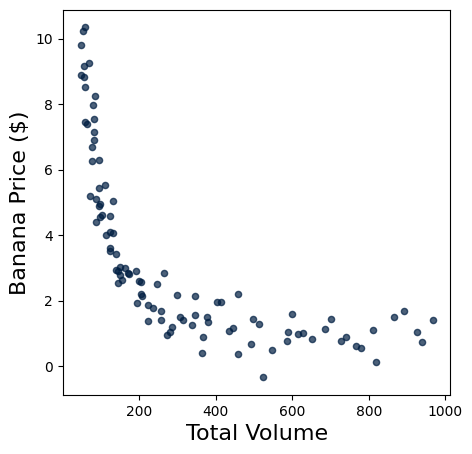

In [ ]:
bananas.scatter("Total Volume", "Banana Price ($)")

In [ ]:
slope, intercept = np.polyfit(bananas.column("Banana Price ($)"),bananas.column("Total Volume"),1)
print(slope, intercept)

-65.7312273084 525.558631062


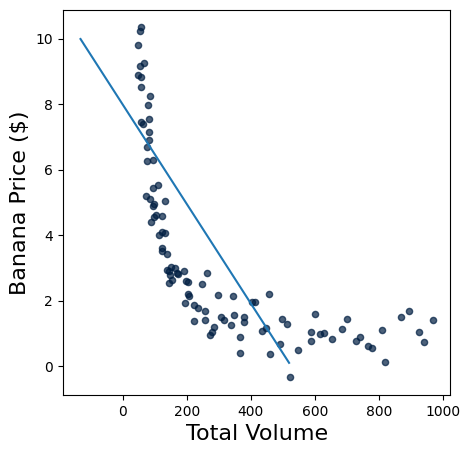

In [ ]:
bananas.scatter("Total Volume", "Banana Price ($)")
prices = np.arange(0.1, 10, 0.01)

plt.plot(slope * prices + intercept, prices)

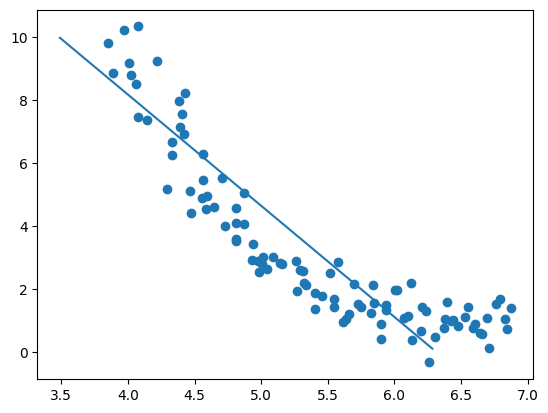

In [ ]:
log_quantity = np.log(bananas.column("Total Volume"))
slope, intercept = np.polyfit(bananas.column("Banana Price ($)"),log_quantity,1)

plt.scatter(log_quantity, bananas.column("Banana Price ($)"))
plt.plot(slope * prices + intercept, prices)

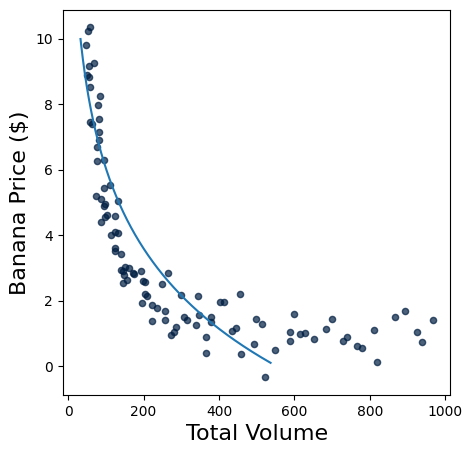

In [ ]:
bananas.scatter("Total Volume", "Banana Price ($)")
plt.plot(np.e ** (slope * prices + intercept), prices)

In [ ]:
#log log

In [ ]:
log_price = np.log(bananas.column("Banana Price ($)"))
mask = ~np.isnan(log_price) & ~np.isnan(log_quantity) & ~np.isinf(log_price) & ~np.isinf(log_quantity)
log_price_clean = log_price[mask]
log_quantity_clean = log_quantity[mask]


slope, intercept = np.polyfit(log_price_clean, log_quantity_clean, 1)
print(slope, intercept)

-0.870390741627 6.11685409353


<ipython-input-8-aa133c5c4c44>:1: RuntimeWarning: invalid value encountered in log
  log_price = np.log(bananas.column("Banana Price ($)"))


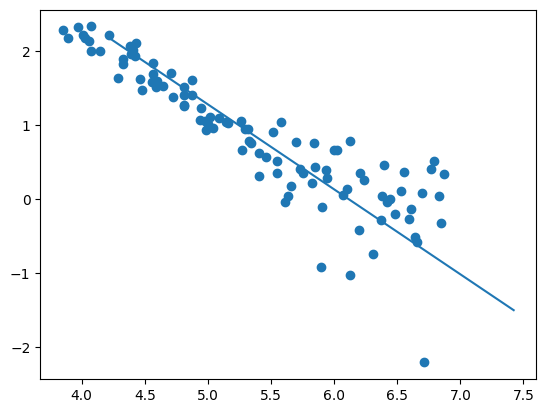

In [ ]:
plt.scatter(log_quantity_clean,log_price_clean)
prices = np.arange(-1.5,2.2, 0.01)
plt.plot(slope * prices + intercept, prices)

In [ ]:
print(prices)

[ 3.8501476  3.9501476  4.0501476  4.1501476  4.2501476  4.3501476
  4.4501476  4.5501476  4.6501476  4.7501476  4.8501476  4.9501476
  5.0501476  5.1501476  5.2501476  5.3501476  5.4501476  5.5501476
  5.6501476  5.7501476  5.8501476  5.9501476  6.0501476  6.1501476
  6.2501476  6.3501476  6.4501476  6.5501476  6.6501476  6.7501476
  6.8501476]


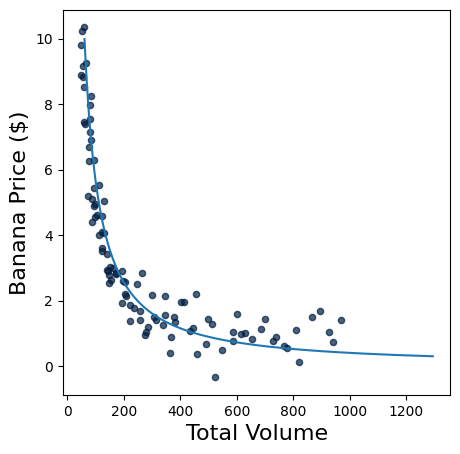

In [ ]:
bananas.scatter("Total Volume", "Banana Price ($)")
prices = np.arange(0.3, 10, 0.01)

equation = ((np.e ** intercept) * (prices ** slope))
plt.plot(equation,prices)
plt.show()


In [ ]:
print('e',intercept,'*','prices','*',slope)

e 6.11685409353 * prices * -0.870390741627


**Simple Knn**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
%matplotlib inline

In [ ]:
# I created a dataset on how money spent on these different aspects effect sales with randomized values
filename = 'Advertising.csv'
df = pd.read_csv(filename)

In [ ]:
# Take a quick look at the dataset
df.head()

In [ ]:
### KNN for k = 1

In [ ]:
# Use the Radio column as the predictor
x_true = df.Radio.iloc[16:25]

# Use the Sales column as the response
y_true = df.Sales.iloc[16:25]

# Sort the data to get indices ordered from lowest to highest Radio values
idx = np.argsort(x_true.values)

# Get the predictor data in the order given by idx above
x_true  = x_true.iloc[idx].values

# Get the response data in the order given by idx above
y_true  = y_true.iloc[idx].values


In [ ]:
# Define a function that finds the index of the nearest neighbor
# and returns the value of the nearest neighbor.
# Note that this is just for k = 1 where the distance function is
# simply the absolute value.

def find_nearest(array,value):

    # Hint: To find idx, use .idxmin() function on the series
    idx = pd.Series(np.abs(array-value)).idxmin()

    # Return the nearest neighbor index and value
    return idx, array[idx]

In [ ]:
# Create some synthetic x-values (might not be in the actual dataset)
x = np.linspace(np.min(x_true), np.max(x_true))

# Initialize the y-values for the length of the synthetic x-values to zero
y = np.zeros((len(x)))

In [ ]:
# Apply the KNN algorithm to predict the y-value for the given x value
for i, xi in enumerate(x):

    # Get the Sales values closest to the given x value
    y[i] = y_true[find_nearest(x_true, xi )[0]]


Plot

In [ ]:
# Plot the synthetic data along with the predictions
plt.plot(x, y, '-.')

# Plot the original data using black x's.
plt.plot(x_true, y_true, 'kx')

# Set the title and axis labels
plt.title('Radio vs Sales')
#plt.xlabel('Radio budget in $1000')
#plt.ylabel('Sales in $1000')

K > 1

In [ ]:
filename = 'Advertising.csv'
df = pd.read_csv(filename)
# let's take a look at the first few lines of the dataset
df.head()

In [ ]:
# Set 'Radio' as the 'predictor variable'
x = df[['Radio']].values

# Set 'Sales' as the response variable 'y'
y = df['Sales'].values

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size= 0.6 ,random_state= 42)

In [ ]:
# Choose the minimum k value based on the instructions given on the left
k_value_min = 1

# Choose the maximum k value based on the instructions given on the left
k_value_max = 70


# Create a list of integer k values betwwen k_value_min and k_value_max using linspace
k_list = np.linspace(k_value_min, k_value_max, 70)

In [ ]:
# Set the grid to plot the values
fig, ax = plt.subplots(figsize=(10,6))

# Variable used to alter the linewidth of each plot
j=0

# Loop over all the k values
for k_value in k_list:

    # Creating a kNN Regression model
    model = KNeighborsRegressor(n_neighbors=int(k_value))

    # Fitting the regression model on the training data
    model.fit(x_train,y_train)

    # Use the trained model to predict on the test data
    y_pred = model.predict(x_test)

    # Helper code to plot the data along with the model predictions
    colors = ['grey','r','b']
    if k_value in [1,10,70]:
        xvals = np.linspace(x.min(),x.max(),100).reshape(-1,1)
        ypreds = model.predict(xvals)
        ax.plot(xvals, ypreds,'-',label = f'k = {int(k_value)}',linewidth=j+2,color = colors[j])
        j+=1

ax.legend(loc='lower right',fontsize=20)
ax.plot(x_train, y_train,'x',label='train',color='k')
ax.set_xlabel('Radio budget in $1000',fontsize=20)
ax.set_ylabel('Sales in $1000',fontsize=20)
plt.tight_layout()


**MSE v. Knn**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
%matplotlib inline

In [ ]:
filename = 'Advertising.csv'
df = pd.read_csv(filename)
# let's take a look at the first few lines of the dataset
df.head()

In [ ]:
# Set 'Radio' as the 'predictor variable'
x = df[['Radio']].values

# Set 'Sales' as the response variable 'y'
y = df['Sales'].values

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size= 0.6 ,random_state= 42)


In [ ]:
# minimum value
k_value_min = 1

# maximum values
k_value_max = 70


# Create a list of integer k values betwwen k_value_min and k_value_max using linspace
k_list = np.linspace(k_value_min, k_value_max, 70)

In [ ]:
# Create a dictionary to store the k value against MSE fit {k: MSE@k}
knn_dict = {}

# Loop over all k values
for k_value in k_list:

    # Create a KNN Regression model for the current k with KNeighborsRegressor()
    model = KNeighborsRegressor(n_neighbors=int(k_value))

    # Fit the model on the train data using .fit()
    model.fit(x_train,y_train)

    # Use the trained model to predict on the test data with .predict()
    y_pred = model.predict(x_test)

    # Calculate the MSE of the predictions
    MSE = mean_squared_error(y_test,y_pred)

    # Store the MSE values of each k value in knn_dict
    knn_dict[k_value] = MSE



In [ ]:
print(knn_dict)

In [ ]:
# Plot a graph which depicts the relation between the k values and MSE
plt.figure(figsize=(8,6))
plt.plot(knn_dict.keys(),knn_dict.values() ,'k.-',alpha=0.5,linewidth=2)

# Set the title and axis labels
plt.xlabel('k',fontsize=20)
plt.ylabel('MSE',fontsize = 20)
plt.title('Test $MSE$ values for different k values - KNN regression',fontsize=20)
plt.tight_layout()